In [2]:
#import needed lib
!pip install pydub
import speech_recognition as sr
import os
from pydub import AudioSegment
from pydub.silence import split_on_silence
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import mean
from numpy import std
import pandas as pd
import numpy as np
import nltk
import re

C:\Users\DELL\Anaconda3\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\utils\validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\feature_extraction\image.py:167: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://

In [3]:
data = pd.read_csv("C:/Users/DELL/Desktop/Final133/dreaddit-train.csv")
print(data)
print(data.isnull().sum())

             subreddit post_id sentence_range  \
0                 ptsd  8601tu       (15, 20)   
1           assistance  8lbrx9         (0, 5)   
2                 ptsd  9ch1zh       (15, 20)   
3        relationships  7rorpp        [5, 10]   
4     survivorsofabuse  9p2gbc         [0, 5]   
...                ...     ...            ...   
3548              ptsd  7vavh4         (0, 5)   
3549     relationships  7oeyuc       [70, 75]   
3550     relationships  7ssxec       (35, 40)   
3551        assistance  90bila        [8, 13]   
3552        assistance  7uueuc        [5, 10]   

                                                   text     id  label  \
0     He said he had not felt that way before, sugge...  33181      1   
1     Hey there r/assistance, Not sure if this is th...   2606      0   
2     My mom then hit me with the newspaper and it s...  38816      1   
3     until i met my new boyfriend, he is amazing, h...    239      1   
4     October is Domestic Violence Awareness M

In [4]:
#data cleaning. use only subreddit for visualization, text and label for train
data = data[['subreddit', 'text', 'label']]
data.head()

,subreddit,text,label
0,ptsd,"He said he had not felt that way before, sugge...",1
1,assistance,"Hey there r/assistance, Not sure if this is th...",0
2,ptsd,My mom then hit me with the newspaper and it s...,1
3,relationships,"until i met my new boyfriend, he is amazing, h...",1
4,survivorsofabuse,October is Domestic Violence Awareness Month a...,1


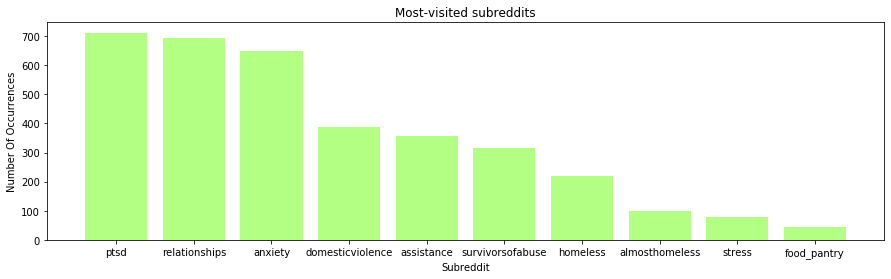

In [5]:
#visualize the most-visited subreddit about stress and mentality 
plt.figure(figsize=(15,4))
plt.bar(data['subreddit'].value_counts().keys().tolist(), data['subreddit'].value_counts().values.tolist(), color=(0.5, 1.0, 0.2, 0.6))
plt.title('Most-visited subreddits')
plt.xlabel('Subreddit')
plt.ylabel('Number Of Occurrences')
plt.show()

In [6]:
#download the nedded lib and stopword for tokenizer
nltk.download('stopwords')
stemmer = nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
import string
stopword=set(stopwords.words('english'))
print(stopword)

{"it's", 'm', 'that', 'should', 'herself', 'those', 'through', 'after', 'out', 'in', "aren't", 'at', 'couldn', 'her', 'when', 'needn', 'doing', "you'll", 'ma', "doesn't", 'no', 'my', 'only', 'him', 'wouldn', 'she', 'by', 'for', 'mustn', 'now', 'has', 'not', 'you', 'it', 't', 'very', 'during', 're', 'once', 'being', 'me', 'while', 'doesn', 'into', 'y', 'or', 'am', 'had', 'above', "you're", 'don', 'having', "should've", 'its', 'i', 'too', 'so', 'we', 'o', 'weren', 'his', 'to', 'before', "isn't", 'of', 'just', "she's", 'yourself', 'do', 'what', 'itself', "mightn't", 'our', 'such', "wouldn't", 'an', 'isn', 'ours', 'against', 'have', 'here', 'their', "that'll", 'who', "shouldn't", 'mightn', 'below', 'over', 'more', 'is', 'own', 'on', 'then', 'any', 'can', 'didn', 'few', "hasn't", "haven't", 'll', 'some', 'these', 'himself', 'shouldn', "hadn't", 'whom', 'if', "weren't", 'haven', 'a', 'from', "don't", 'are', 'will', 'does', 'been', 'were', 'the', 's', 'nor', 'yourselves', 'aren', 'won', 'and'

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
#Tokenizer to "clean" the speech and text
def dataCleaning(inputt):
    inputt = str(inputt).lower()
    inputt = re.sub('\w*\d\w*', '', inputt)
    inputt = re.sub('\[.*?\]', '', inputt)
    inputt = re.sub('<.*?>+', '', inputt)
    inputt = re.sub('\n', '', inputt)
    inputt = re.sub('https?://\S+|www\.\S+', '', inputt)
    inputt = re.sub('[%s]' % re.escape(string.punctuation), '', inputt)
    result = []
    for word in inputt.split(' '):
        if word not in stopword:
            result.append(word)
    result= " ".join(result)
    return result
data["text"] = data["text"].apply(dataCleaning)
print(data.text)

0       said felt way suggeted go rest trigger ahead y...
1       hey rassistance sure right place post goes  im...
2       mom hit newspaper shocked would knows dont lik...
3       met new boyfriend amazing kind sweet good stud...
4       october domestic violence awareness month dome...
                              ...                        
3548    horrible vivid nightmares every night sometime...
3549    also cant think without getting angry jealous ...
3550    furthermore told got really serious anxiety de...
3551    heres link amazon wish list two items  link do...
3552    keep us protected already told unwelcome perso...
Name: text, Length: 3553, dtype: object


In [8]:
#install wordcloud
!pip install wordcloud

0       said felt way suggeted go rest trigger ahead y...
1       hey rassistance sure right place post goes  im...
2       mom hit newspaper shocked would knows dont lik...
3       met new boyfriend amazing kind sweet good stud...
4       october domestic violence awareness month dome...
                              ...                        
3548    horrible vivid nightmares every night sometime...
3549    also cant think without getting angry jealous ...
3550    furthermore told got really serious anxiety de...
3551    heres link amazon wish list two items  link do...
3552    keep us protected already told unwelcome perso...
Name: text, Length: 3553, dtype: object


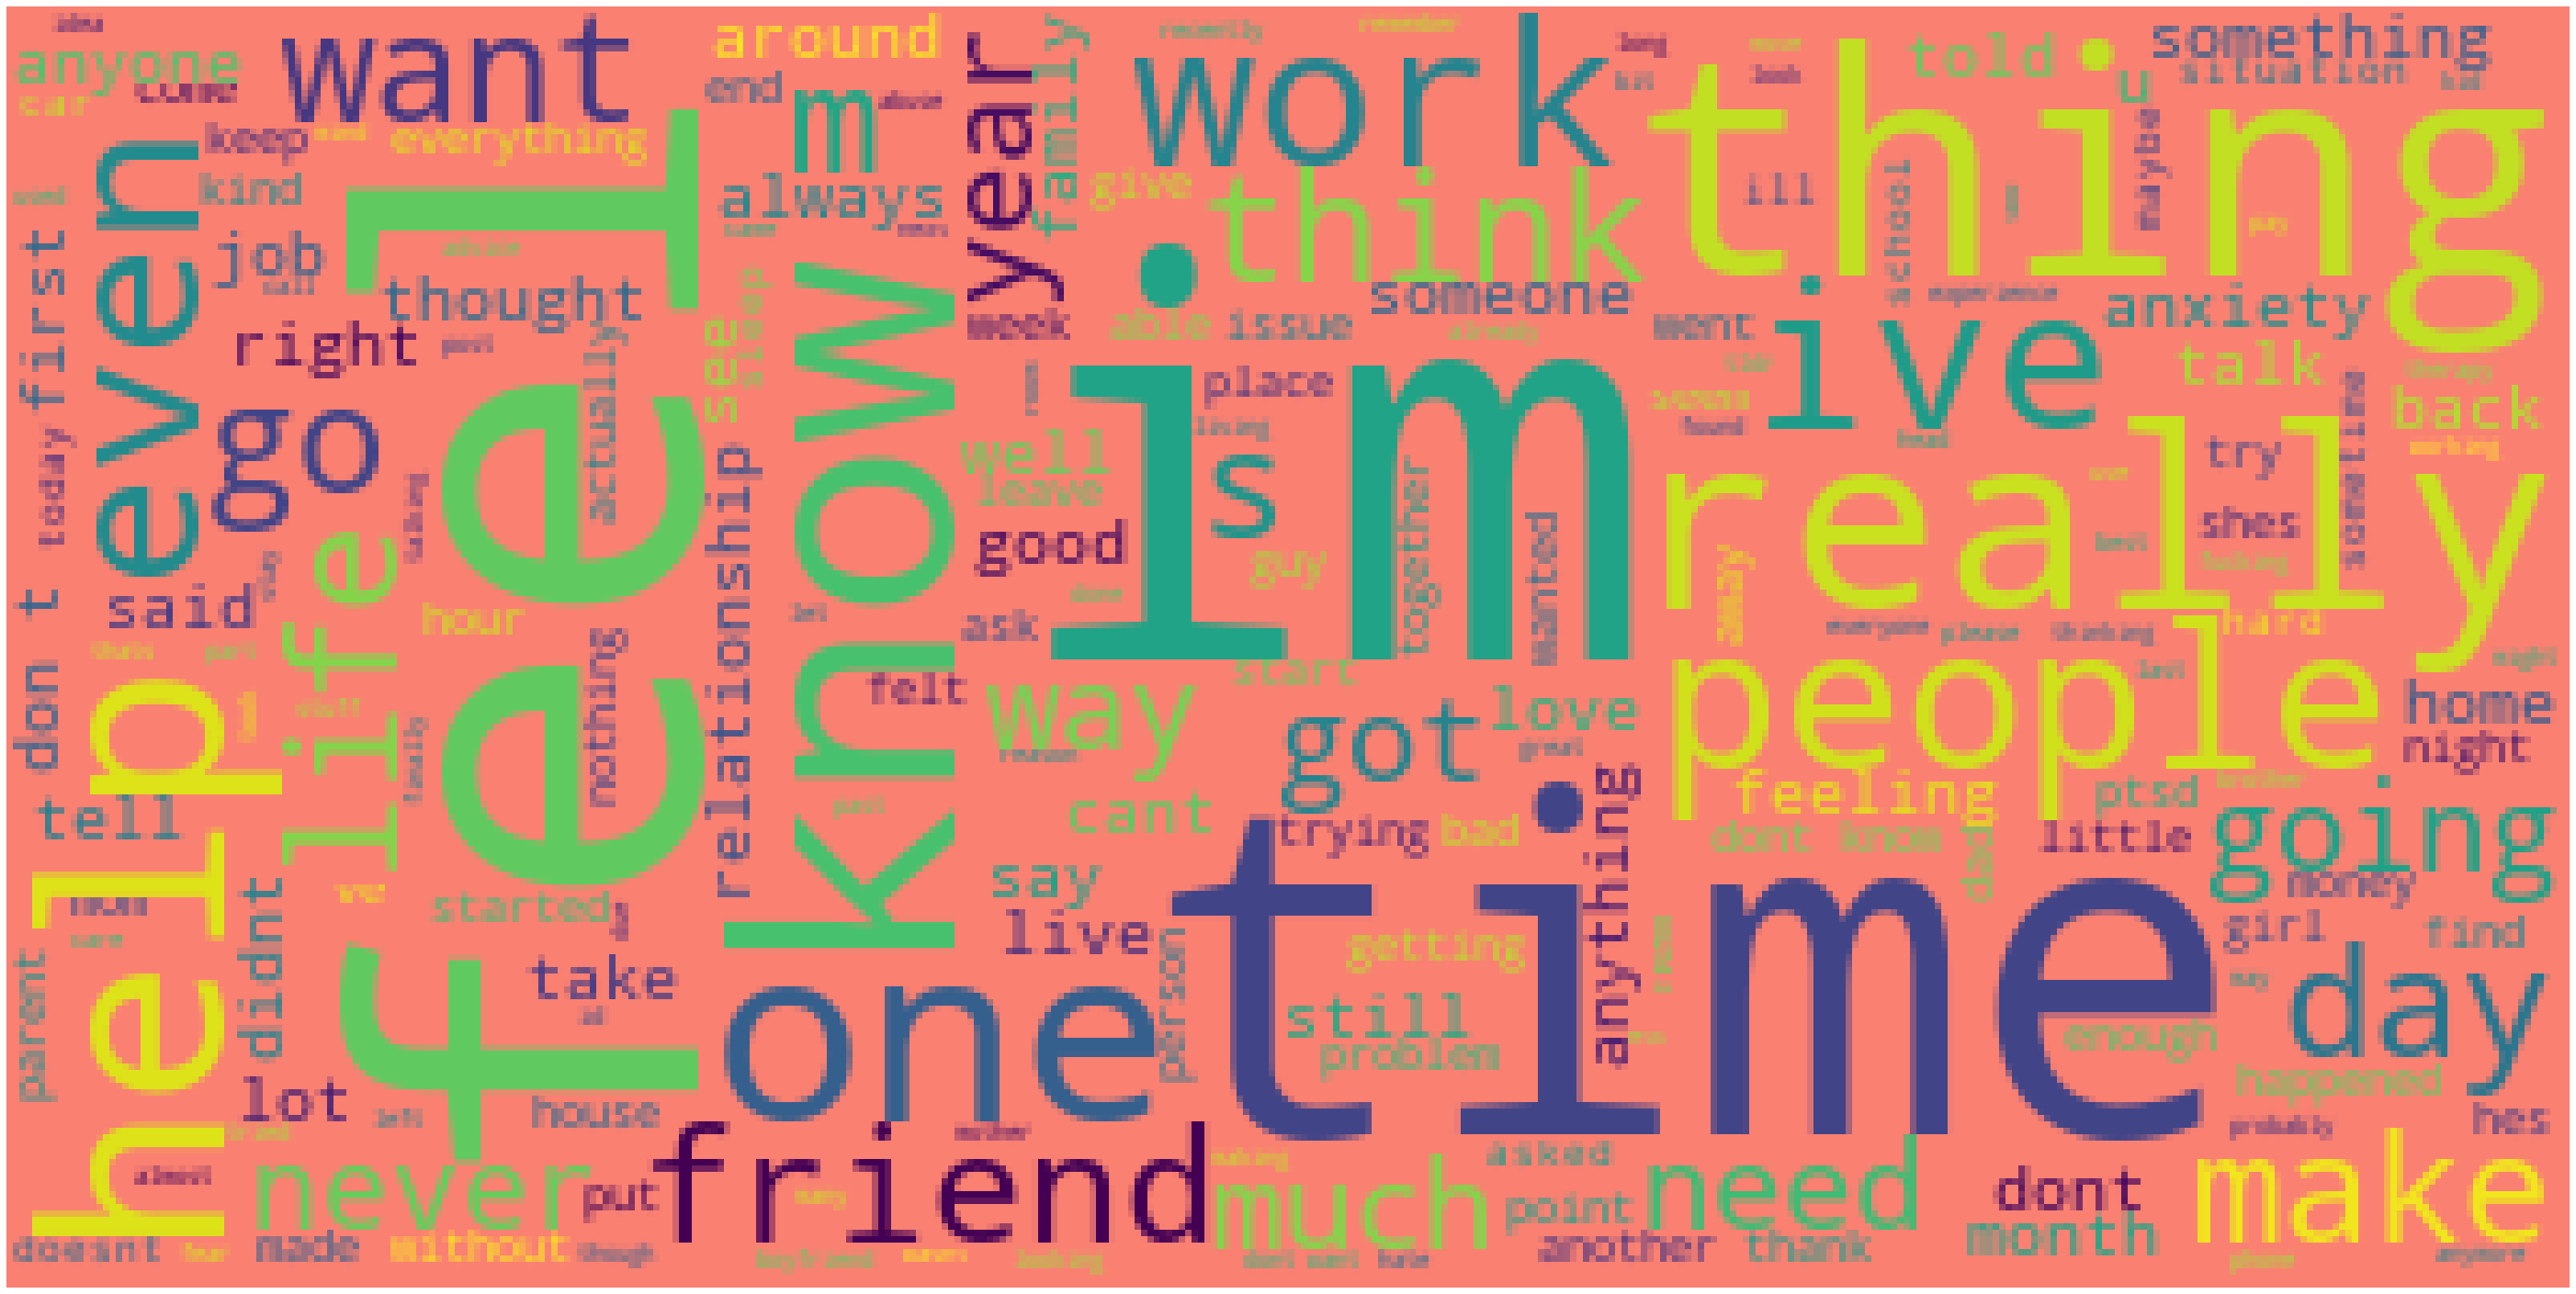

In [10]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
text = " ".join(i for i in data.text)
print(data.text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, 
                      background_color="salmon").generate(text)
plt.figure( figsize=(50,30))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

[('im', 1715), ('like', 1503), ('get', 1083), ('know', 1052), ('feel', 966), ('time', 947), ('would', 941), ('dont', 927), ('really', 813), ('even', 752), ('want', 694), ('one', 691), ('ive', 679), ('help', 646), ('go', 615), ('people', 577), ('going', 555), ('back', 549), ('things', 521), ('years', 515), ('anxiety', 512), ('never', 507), ('i’m', 504), ('work', 496), ('much', 488), ('think', 486), ('life', 482), ('got', 481), ('also', 479), ('could', 475), ('day', 460), ('cant', 449), ('still', 433), ('something', 425), ('need', 419), ('friends', 416), ('make', 405), ('told', 390), ('way', 374), ('see', 365), ('since', 360), ('first', 360), ('anyone', 357), ('family', 353), ('said', 349), ('year', 341), ('anything', 341), ('didnt', 339), ('job', 331), ('good', 330)]


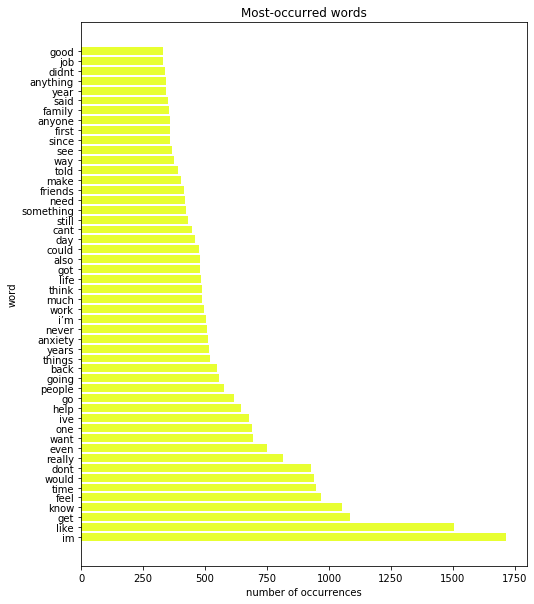

In [11]:
from collections import Counter

# split() returns list of all the words in the string
split_it = text.split()
  
# Pass the split_it list to instance of Counter class.
Counter = Counter(split_it)
  
# most_common() produces k frequently encountered
# input values and their respective counts.
most_occur = Counter.most_common(50)
print(most_occur)
wordName = [pair[0] for pair in most_occur]
wordCount = [pair[1] for pair in most_occur]
plt.figure(figsize=(8, 10))
plt.barh(wordName, wordCount, color=(0.9, 1.0, 0.1, 0.9))
plt.title('Most-occurred words')
plt.xlabel('number of occurrences')
plt.ylabel('word')
plt.show()

In [12]:
#rename the label
data["label"] = data["label"].map({0: "No Stress", 1: "Stress"})
data = data[["text", "label"]]
print(data.head())

                                                text      label
0  said felt way suggeted go rest trigger ahead y...     Stress
1  hey rassistance sure right place post goes  im...  No Stress
2  mom hit newspaper shocked would knows dont lik...     Stress
3  met new boyfriend amazing kind sweet good stud...     Stress
4  october domestic violence awareness month dome...     Stress


In [13]:
#split the dataset into train and test dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

x = np.array(data["text"])
print(x)
y = np.array(data["label"])
print(y)
cv = CountVectorizer()
X = cv.fit_transform(x)

['said felt way suggeted go rest trigger ahead youire hypocondriac like decide look feelings doom hopes maybe getting sucked rabbit hole ludicrous conspiracy stupid psychic test new age bs something could even laugh road ended reading sense doom indicative various health ailments one prone top doom gloomi fn worried heart happen physical  hours'
 'hey rassistance sure right place post goes  im currently student intern sandia national labs working survey help improve marketing outreach efforts many schools recruit around country looking current undergradgrad stem students youre stem student know stem students would greatly appreciate help take pass along short survey thank everyone helps take survey entered drawing chance win one three  amazon gcs'
 'mom hit newspaper shocked would knows dont like play hitting smacking striking hitting violence sort person send vibe asking universe yesterday decided take friend go help another friend move new place driving friend moving strikes shoulder

In [20]:
import warnings
warnings.filterwarnings('ignore')
#binary classification using BernoulliNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
model1 = BernoulliNB()
model2 = RandomForestClassifier()
model3 = LogisticRegression()
model4 = AdaBoostClassifier();
model5 = KNeighborsClassifier()
model6 = SVC()

TrainScore1 = []
TrainScore2 = []
TrainScore3 = []
TrainScore4 = []
TrainScore5 = []
TrainScore6 = []

TestScore1 = []
TestScore2 = []
TestScore3 = []
TestScore4 = []
TestScore5 = []
TestScore6 = []

#Train the dataset and calculate the score of the train 10 times to define which model is best for our goal
for i in range (0, 10): 
    #split the data into 8 parts for train and 2 parts for test
    xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
    model1.fit(xtrain, ytrain)
    model2.fit(xtrain, ytrain)
    model3.fit(xtrain, ytrain)
    model4.fit(xtrain, ytrain)
    model5.fit(xtrain, ytrain)
    model6.fit(xtrain, ytrain)

    TrainScore1.append(model1.score(xtrain, ytrain))
    TrainScore2.append(model2.score(xtrain, ytrain))
    TrainScore3.append(model3.score(xtrain, ytrain))
    TrainScore4.append(model4.score(xtrain, ytrain))
    TrainScore5.append(model5.score(xtrain, ytrain))
    TrainScore6.append(model6.score(xtrain, ytrain))
    
    TestScore1.append(model1.score(xtest, ytest))
    TestScore2.append(model2.score(xtest, ytest))
    TestScore3.append(model3.score(xtest, ytest))
    TestScore4.append(model4.score(xtest, ytest))
    TestScore5.append(model5.score(xtest, ytest))
    TestScore6.append(model6.score(xtest, ytest))


modelsTrainScore = dict()    
modelsTrainScore['Bernoulli'] = TrainScore1
modelsTrainScore['Random Forest'] = TrainScore2
modelsTrainScore['Logistic Regression'] = TrainScore3
modelsTrainScore['Adaboost'] = TrainScore4
modelsTrainScore['KNN'] = TrainScore5
modelsTrainScore['Support Vector Machine'] = TrainScore6

modelsTestScore = dict()
modelsTestScore['Bernoulli'] = TestScore1
modelsTestScore['Random Forest'] = TestScore2
modelsTestScore['Logistic Regression'] = TestScore3
modelsTestScore['Adaboost'] = TestScore4
modelsTestScore['KNN'] = TestScore5
modelsTestScore['Support Vector Machine'] = TestScore6
    

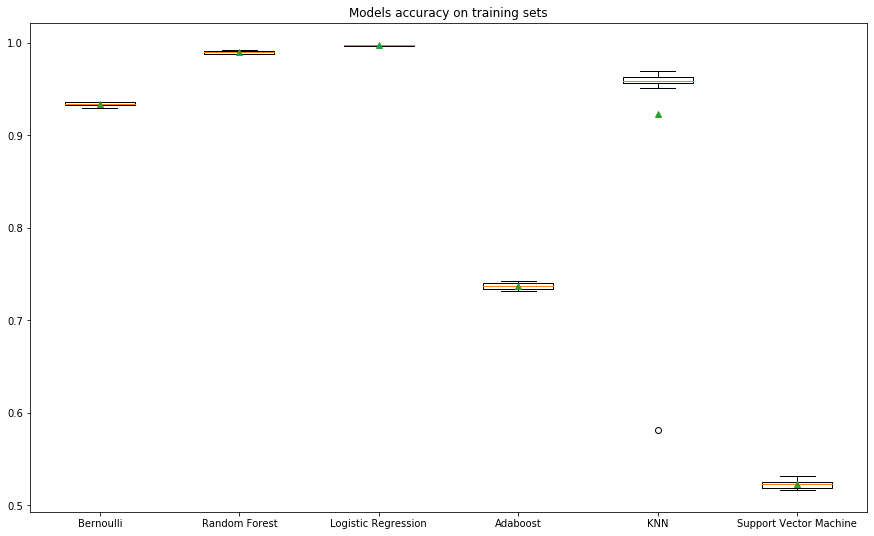

In [21]:
#visualize the result

# evaluate the models and store results
results, names = list(), list()
for name, model in modelsTrainScore.items():
    results.append(model)
    names.append(name)
# plot model performance for comparison
plt.figure(figsize=(15, 9))
plt.title("Models accuracy on training sets")
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

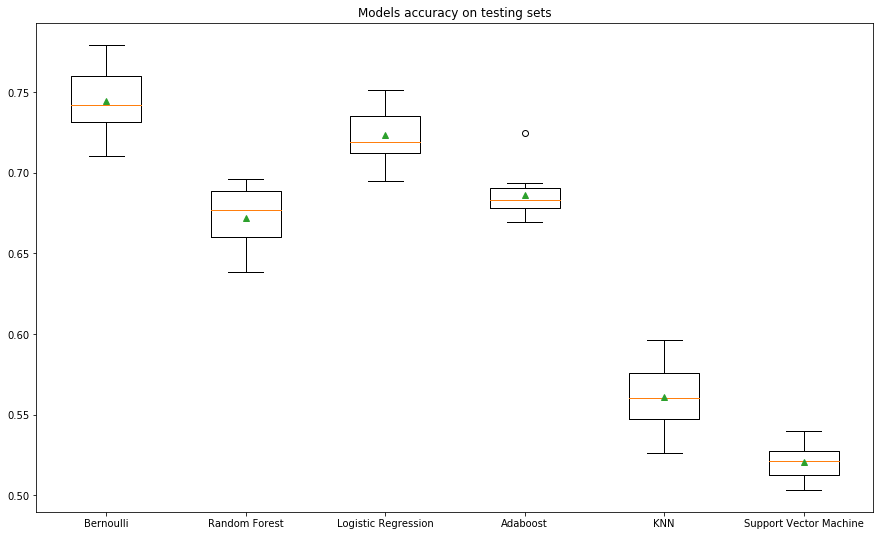

In [16]:
#visualize the result


# evaluate the models and store results
results, names = list(), list()
for name, score in modelsTestScore.items():
    results.append(score)
    names.append(name)
plt.figure(figsize=(15, 9))
plt.title("Models accuracy on testing sets")
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

[0.9339549612948627, 0.989408866995074, 0.997079521463758, 0.7364532019704434, 0.9145672061928218, 0.5231878958479943]
[0.7444444444444445, 0.6718706047819972, 0.7232067510548523, 0.6860759493670885, 0.5606188466947961, 0.520534458509142]


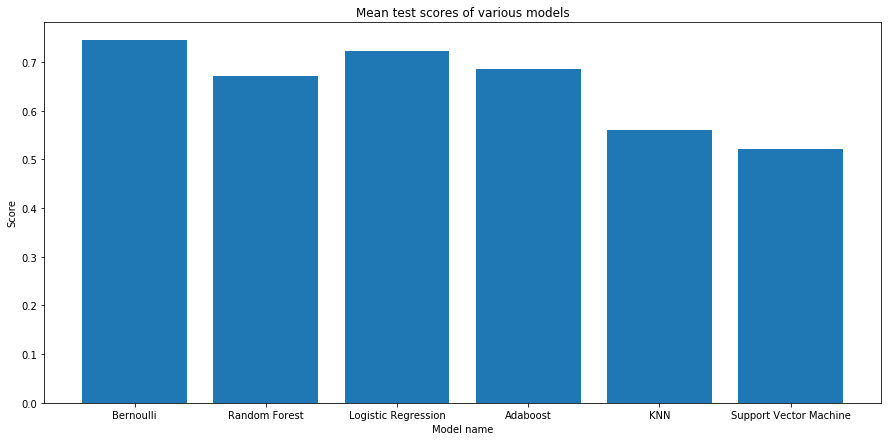

In [17]:
MeanTrainScoreModels = [mean(TrainScore1), mean(TrainScore2), mean(TrainScore3), mean(TrainScore4), mean(TrainScore5), mean(TrainScore6)]
print(MeanTrainScoreModels)
MeanTestScoreModels = [mean(TestScore1), mean(TestScore2), mean(TestScore3), mean(TestScore4), mean(TestScore5), mean(TestScore6)]
print(MeanTestScoreModels)
modelNames = ['Bernoulli', 'Random Forest', 'Logistic Regression', 'Adaboost', 'KNN', 'Support Vector Machine']
plt.figure(figsize=(15, 7))
plt.bar(modelNames, MeanTestScoreModels)
plt.title('Mean test scores of various models')
plt.xlabel('Model name')
plt.ylabel('Score')
plt.show()

In [52]:
print("Talk ")
r = sr.Recognizer();
with sr.Microphone() as source:
    # read the audio data from the default microphone
    audio_data = r.record(source, duration=7)
    print("Talk: ")
    # convert speech to text
    text = r.recognize_google(audio_data)
    print(text)

Talk 
Talk: 
I lost many many of my relationships I feel so sad but I also have new relationship


In [53]:
user = text
inputed = cv.transform([user]).toarray()
output = model1.predict(inputed)
print(output)



['No Stress']
